# Analysis 8 — Model Interpretability
### A tutorial walkthrough

**Dataset:** `2026-05-21_22-59_Method Dev_wavelength_range_1450-2450.xlsx`
**Plan reference:** `ANALYSIS_PLAN.md` → Analysis 8

---

#### Why bother "interpreting" a model?

In the earlier notebooks we built models that classify a flooring scan as vinyl or hardwood (and
which species / wear-layer) with 95–100 % accuracy. That answers *what* the model predicts. This
notebook answers a different, equally important question: **why?**

A near-infrared (NIR) spectrum is just 249 numbers — the slope of light absorption at 249
wavelengths from 1454 to 2446 nm. A model like XGBoost can combine those 249 numbers in
complicated, non-linear ways. "Interpretability" is the toolkit for cracking that box open and
asking:

- *Which wavelengths actually drive the decision?* (global importance)
- *How does the prediction change as a wavelength's value changes?* (dependence / partial
  dependence)
- *Why was this one specific scan classified the way it was?* (local explanations)

This matters for science, not just curiosity. If the model leans on the wavelengths where C–H and
O–H chemical bonds absorb (the bonds that genuinely differ between plastic and wood), we can
*trust* it. If it leans on some random wavelength, that's a red flag — maybe it found a shortcut
that won't generalise.

We will use five complementary tools, from most to least familiar:

| Tool | Question it answers | Scope |
|------|--------------------|-------|
| **Permutation importance** | If I scramble this wavelength, how much worse does the model get? | Global |
| **SHAP** | How much did each wavelength push *this* prediction up or down? | Local **and** global |
| **Partial dependence (PDP)** | On average, how does the prediction respond to this wavelength's value? | Global |
| **LIME** | What's a simple, local story for why *this scan* got *this label*? | Local |
| **Consensus ranking** | Which wavelengths do *all* methods agree are important? | Global |

By the end we should see the same handful of wavelength regions — the C–H overtone bands near
**1690–1710 nm** and **2240–2270 nm** — float to the top no matter which method we ask. That
agreement is the real result.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.feature_selection import RFE, f_classif
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
import shap
import lime
import lime.lime_tabular

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11
})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Libraries loaded. shap', shap.__version__)

Libraries loaded. shap 0.49.1


## 1. Load the data and build labels

Nothing new here — this is the exact same loading and label-parsing code used in the other
notebooks, so our results line up with theirs. The Excel file has two sheets: **sheet 1** is the
spectra (one column per scan, one row per wavelength), **sheet 0** is the free-text description of
each scan. `parse_desc()` turns those descriptions into structured fields (vinyl vs lumber, wear
layer, species) and throws away calibration scans (water/test).

In [2]:
FILE = '../2026-05-21_22-59_Method Dev_wavelength_range_1450-2450.xlsx'
spec_df = pd.read_excel(FILE, sheet_name=1)
meta_df = pd.read_excel(FILE, sheet_name=0)

wavelengths = spec_df['Wavelength (nm)'].values
spec_cols   = [c for c in spec_df.columns if c != 'Wavelength (nm)']
meta_dict   = dict(zip(meta_df['Spectrum ID'], meta_df['Measurement Description']))

def parse_desc(d):
    """Parse a trinamiX Measurement Description into a structured dict."""
    d = d.strip()
    if d.lower().startswith('water') or d.lower().startswith('test'):
        return None
    parts = [p.strip() for p in d.split(',')]
    if parts[0].lower() == 'vinyl':
        wl = None; price = None; color_parts = []
        brand = parts[1].strip() if len(parts) > 1 else 'unknown'
        for p in parts[2:]:
            p = p.strip()
            if p.lower().startswith('wl '):
                try:   wl = float(p.split()[1])
                except: pass
            else:
                try:   price = float(p)
                except: color_parts.append(p)
        return {'type': 'LVP', 'brand': brand, 'wear_layer': wl,
                'price': price, 'color': ' '.join(color_parts), 'desc': d}
    elif parts[0].lower() == 'lumber':
        species = parts[1].strip() if len(parts) > 1 else 'unknown'
        return {'type': 'Hardwood', 'species': species.strip(), 'desc': d}
    return None

rows = []
for sid in spec_cols:
    desc = meta_dict.get(sid)
    if not desc: continue
    parsed = parse_desc(str(desc))
    if not parsed: continue
    rows.append({'id': sid, **parsed, 'spectrum': spec_df[sid].values})

df = pd.DataFrame([{k: v for k, v in r.items() if k != 'spectrum'} for r in rows])
spectra = np.array([r['spectrum'] for r in rows])
print(f'Usable scans: {len(rows)}  |  wavelengths: {spectra.shape[1]}  '
      f'({wavelengths.min():.0f}-{wavelengths.max():.0f} nm)')

Usable scans: 134  |  wavelengths: 249  (1454-2446 nm)


## 2. Preprocessing — the same two chemometric fixes

Raw NIR spectra carry nuisances unrelated to chemistry (overall brightness shifts from how the
probe sat on the surface, scattering, baseline drift). We remove them with the two standard moves:

- **SNV (Standard Normal Variate):** centre and scale each spectrum individually, so only its
  *shape* matters, not its overall level.
- **Savitzky–Golay 1st derivative:** replace each curve with its smooth *slope*, which kills slow
  baseline drift and sharpens the peaks.

After this, every feature column is "the derivative value at wavelength *w*". We give each feature
a human-readable name — its wavelength in nm — because interpretability is all about pointing back
to a physical wavelength.

In [3]:
def snv(X):
    return (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

def sg1(X, window=11, polyorder=2):
    return savgol_filter(X, window_length=window, polyorder=polyorder, deriv=1, axis=1)

X_all = sg1(snv(spectra))
feat_names = [f'{w:.0f}nm' for w in wavelengths]   # e.g. '1698nm'
wl_round   = np.round(wavelengths).astype(int)
print('Preprocessed feature matrix:', X_all.shape, '| first feature:', feat_names[0])

Preprocessed feature matrix: (134, 249) | first feature: 1454nm


## 3. The labels we will explain

We focus on the **9-class** task — the full label for each scan — because it is the one the plan
asks us to interpret, and it is rich enough to be interesting:

- `LVP_6`, `LVP_12`, `LVP_22` — vinyl plank, by wear-layer thickness (mil)
- `HW_fir`, `HW_mahogany`, `HW_oak`, `HW_pine`, `HW_poplar`, `HW_particle board` — wood, by species

We also build a simple **binary** label (vinyl vs hardwood). Some interpretability plots — the
classic SHAP "beeswarm" especially — are far easier to read when there are only two classes, so
we'll use the binary model for those and the 9-class model for the rest.

`LabelEncoder` just turns the text labels into integers `0,1,2,…` that the models expect; we keep
the mapping so we can translate back to readable names in every plot.

In [4]:
def class9(r):
    return f"LVP_{int(r['wear_layer'])}" if r['type'] == 'LVP' else f"HW_{r['species']}"

y9_text = df.apply(class9, axis=1).values
le9 = LabelEncoder().fit(y9_text)
y9  = le9.transform(y9_text)
class9_names = list(le9.classes_)

yb_text = df['type'].values                       # 'LVP' / 'Hardwood'
leb = LabelEncoder().fit(yb_text)
yb  = leb.transform(yb_text)                       # Hardwood=0, LVP=1
binary_names = list(leb.classes_)

print('9-class labels :', dict(pd.Series(y9_text).value_counts()))
print('Binary labels  :', dict(zip(binary_names, np.bincount(yb))))

9-class labels : {'LVP_6': np.int64(33), 'LVP_12': np.int64(30), 'LVP_22': np.int64(27), 'HW_pine': np.int64(11), 'HW_fir': np.int64(10), 'HW_mahogany': np.int64(6), 'HW_oak': np.int64(6), 'HW_poplar': np.int64(6), 'HW_particle board': np.int64(5)}
Binary labels  : {'Hardwood': np.int64(44), 'LVP': np.int64(90)}


## 4. Train the models we'll interpret

We train three models. They are deliberately ordinary — the point of this notebook isn't to win
on accuracy, it's to *understand* a competent model.

- **`xgb9`** — XGBoost on the 9-class task. This is our headline model.
- **`xgb_bin`** — XGBoost on the binary task. Used for the cleanest SHAP pictures.
- **`rf9`** — a Random Forest on the 9-class task. Permutation importance and PDP run on this one,
  so we can check whether a *different* model family agrees with XGBoost about which wavelengths
  matter. Agreement across model families is strong evidence the importance is real.

We report 5-fold cross-validated accuracy so you can see the models are genuinely good before we
start trusting their explanations. For the local-explanation tools (SHAP force plots, LIME) we
keep a held-out test split so we explain predictions the model never saw during training.

In [5]:
Xtr, Xte, ytr, yte = train_test_split(
    X_all, y9, test_size=0.30, stratify=y9, random_state=RANDOM_STATE)

xgb_kw = dict(n_estimators=300, max_depth=3, learning_rate=0.1,
              subsample=0.9, colsample_bytree=0.8,
              random_state=RANDOM_STATE, n_jobs=-1, eval_metric='mlogloss')

xgb9 = XGBClassifier(objective='multi:softprob', num_class=len(class9_names), **xgb_kw)
xgb9.fit(Xtr, ytr)

rf9 = RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)
rf9.fit(Xtr, ytr)

xgb_bin = XGBClassifier(objective='binary:logistic', n_estimators=300, max_depth=3,
                        learning_rate=0.1, subsample=0.9, colsample_bytree=0.8,
                        random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss')
xgb_bin.fit(X_all, yb)   # binary model is just for explanation, fit on everything

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
acc_xgb9 = cross_val_score(XGBClassifier(objective='multi:softprob',
                           num_class=len(class9_names), **xgb_kw),
                           X_all, y9, cv=cv).mean()
acc_rf9  = cross_val_score(RandomForestClassifier(n_estimators=400,
                           random_state=RANDOM_STATE, n_jobs=-1), X_all, y9, cv=cv).mean()
acc_bin  = cross_val_score(XGBClassifier(objective='binary:logistic', n_estimators=300,
                           max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE,
                           n_jobs=-1, eval_metric='logloss'), X_all, yb, cv=cv).mean()

print(f'5-fold CV accuracy')
print(f'  XGBoost  9-class : {acc_xgb9:.1%}   (LDA baseline 96.3%)')
print(f'  RandomF. 9-class : {acc_rf9:.1%}')
print(f'  XGBoost  binary  : {acc_bin:.1%}')
print(f'Held-out test accuracy (xgb9): {accuracy_score(yte, xgb9.predict(Xte)):.1%}')

5-fold CV accuracy
  XGBoost  9-class : 92.5%   (LDA baseline 96.3%)
  RandomF. 9-class : 97.0%
  XGBoost  binary  : 99.3%
Held-out test accuracy (xgb9): 95.1%


## 5. SHAP — the workhorse of modern interpretability

**SHAP (SHapley Additive exPlanations)** comes from cooperative game theory. Imagine the 249
wavelengths are players on a team, and the "payout" is the model's prediction for one scan. The
**Shapley value** of a wavelength is its fair share of the credit: averaged over every possible
order in which you could add players to the team, how much does *this* wavelength change the
prediction?

The beautiful property is **additivity**: for any single scan,

> (model output) = (baseline / average output) + Σ (SHAP value of each wavelength)

So SHAP values are in the *units of the prediction* and they literally add up to explain the gap
between "what the model says on average" and "what it says for this scan". A positive SHAP value
for a wavelength means *that wavelength pushed this prediction toward the class*; negative means it
pushed away.

For tree models (XGBoost, Random Forest) SHAP has a fast exact algorithm called **TreeExplainer**,
so we don't have to approximate. We start with the **binary** model because its SHAP output is a
single number per wavelength per scan — perfect for the iconic *beeswarm* plot.

SHAP value array: (134, 249) (scans x wavelengths)


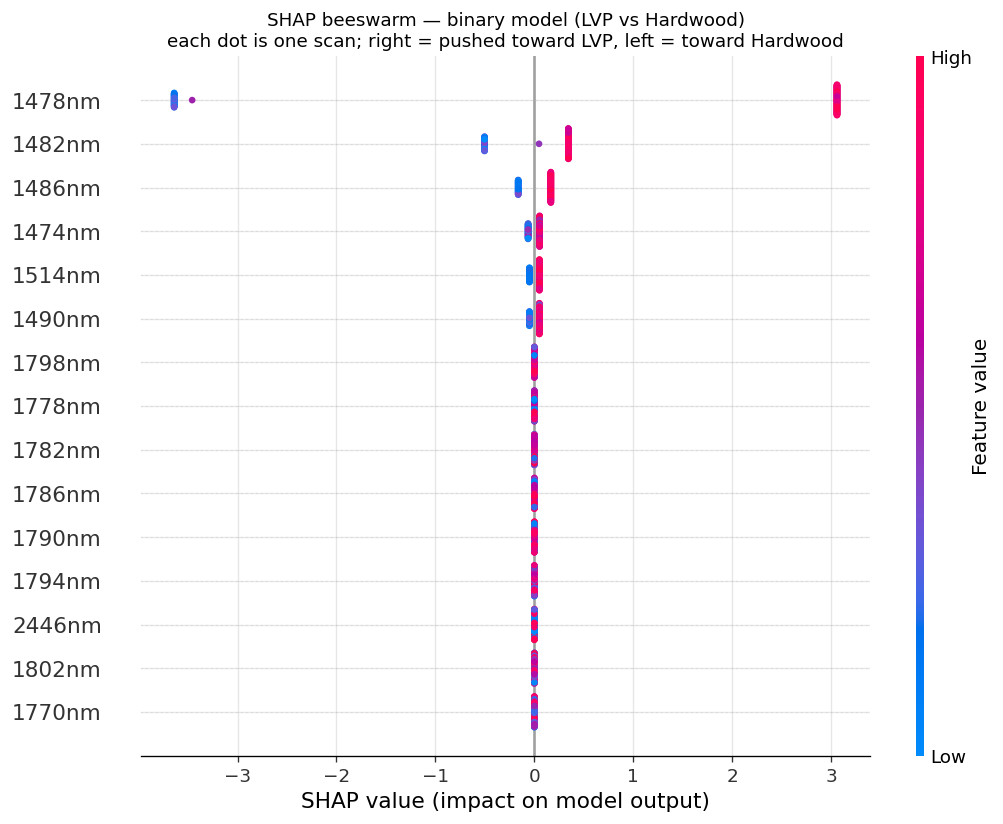

In [6]:
# --- SHAP for the BINARY model (cleanest to read) -----------------------------
expl_bin = shap.TreeExplainer(xgb_bin)
sv_bin   = expl_bin.shap_values(X_all)            # shape (n_scans, n_wavelengths)
print('SHAP value array:', np.asarray(sv_bin).shape, '(scans x wavelengths)')

Xdf = pd.DataFrame(X_all, columns=feat_names)

fig = plt.figure(figsize=(9, 7))
shap.summary_plot(sv_bin, Xdf, max_display=15, show=False, plot_size=None)
plt.title(f'SHAP beeswarm — binary model ({binary_names[1]} vs {binary_names[0]})\n'
          'each dot is one scan; right = pushed toward LVP, left = toward Hardwood',
          fontsize=11)
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=130)
plt.show()

The pattern to look for: a row where red and blue dots cleanly separate left/right means *the value
of the spectrum at that wavelength reliably flips the decision*. Here the binary model leans hardest
on the **1470–1520 nm band** (look at 1478 nm: high derivative values — red — shove the prediction
strongly toward LVP, low values toward hardwood), with a secondary cluster near **1770–1800 nm**.
Both sit in O–H / C–H overtone territory, exactly where a plastic surface and a wood surface diverge.

A note on what comes next: vinyl-vs-hardwood is an *easy* split, so the model only needs one clean
region to nail it. The harder 9-class task spreads its attention across more bands — which is why the
multi-method consensus in section 9 surfaces a slightly different (and broader) set of wavelengths.

### SHAP dependence — zooming into one wavelength

A beeswarm shows *which* wavelengths matter. A **dependence plot** shows *how*. For one wavelength
we plot, across all scans, the spectrum's value at that wavelength (x) against its SHAP value (y).
The shape of that cloud tells you the functional relationship the model learned — flat, linear, or
a sharp threshold (a step), which is the signature of a tree carving the feature at a cut point.

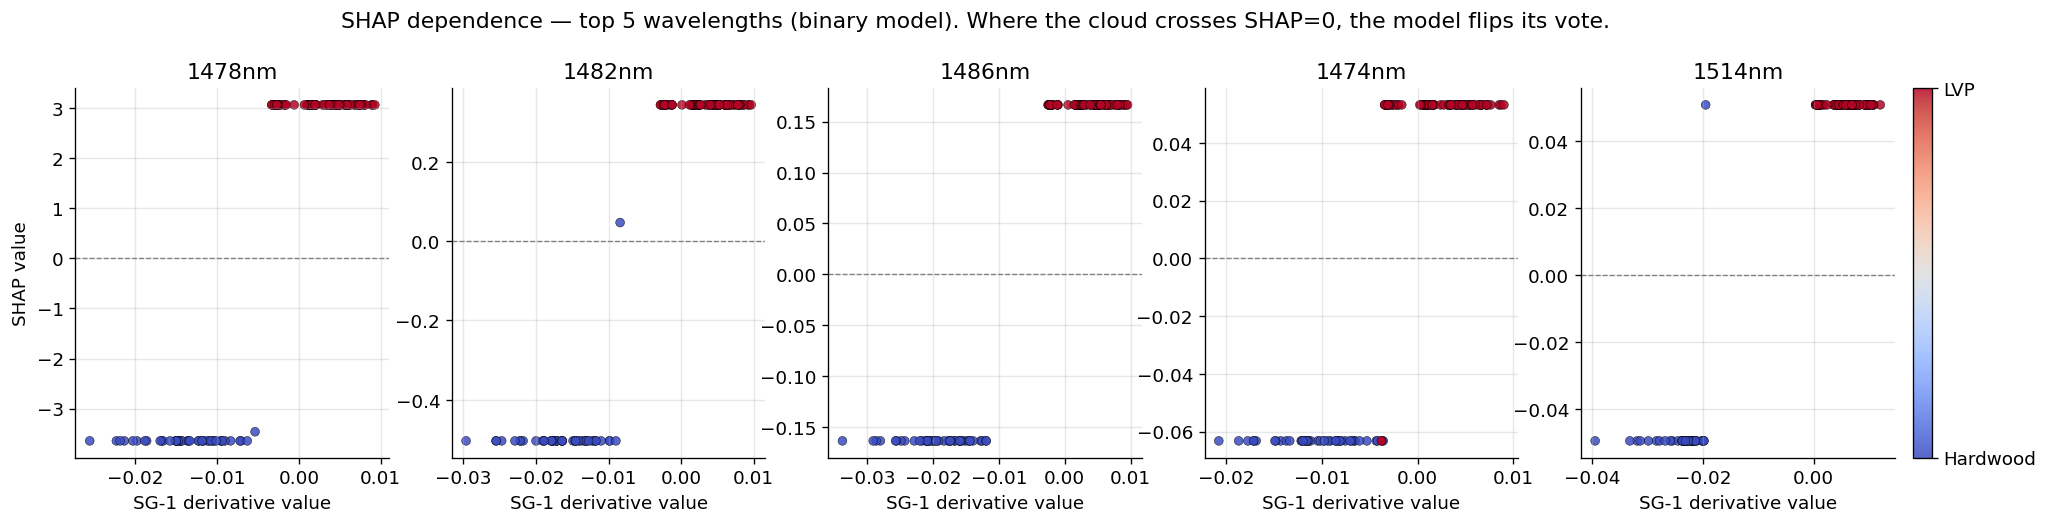

In [7]:
# Top wavelengths by mean |SHAP| in the binary model
mean_abs_bin = np.abs(sv_bin).mean(axis=0)
top5_idx = np.argsort(mean_abs_bin)[::-1][:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, idx in zip(axes, top5_idx):
    xv = X_all[:, idx]
    yv = sv_bin[:, idx]
    sc = ax.scatter(xv, yv, c=yb, cmap='coolwarm', s=28, edgecolor='k', linewidth=0.3, alpha=0.85)
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_title(f'{feat_names[idx]}')
    ax.set_xlabel('SG-1 derivative value')
    ax.set_ylabel('SHAP value' if idx == top5_idx[0] else '')
cbar = fig.colorbar(sc, ax=axes, fraction=0.012, pad=0.01)
cbar.set_ticks([0, 1]); cbar.set_ticklabels(binary_names)
fig.suptitle('SHAP dependence — top 5 wavelengths (binary model). '
             'Where the cloud crosses SHAP=0, the model flips its vote.', y=1.04)
plt.savefig('shap_dependence.png', bbox_inches='tight', dpi=130)
plt.show()

### Explaining one scan — the additive breakdown

SHAP's additivity lets us fully account for a *single* prediction. Below we take one test scan and
list the wavelengths that pushed hardest for and against the predicted class. Read it as a tug-of-war:
start at the model's average output, add each wavelength's push, and you land on the final
prediction. This is the kind of explanation you could hand to a domain expert to sanity-check a
single measurement.

9-class SHAP array: (41, 249, 9) (scans x wavelengths x classes)


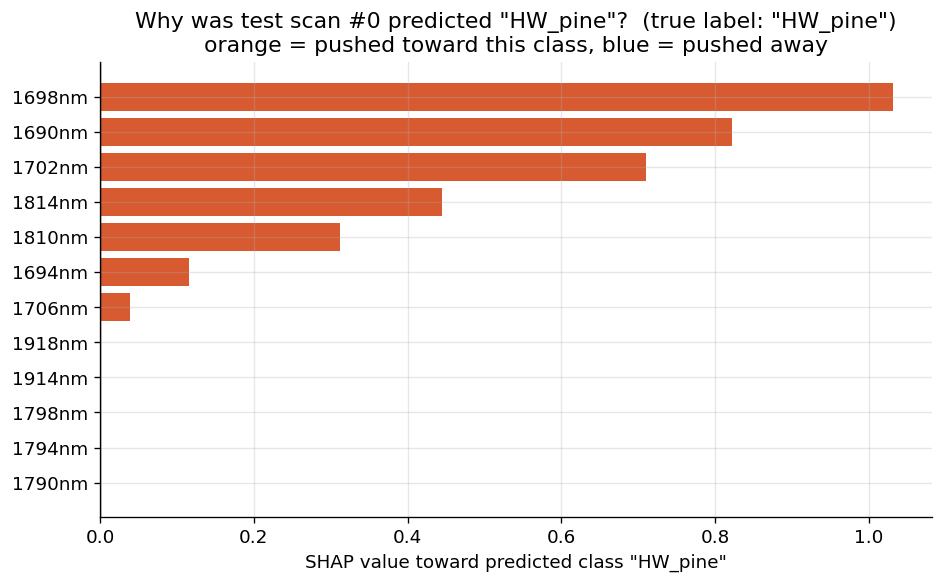

In [8]:
# Use the 9-class model. SHAP for multiclass tree models -> (n, features, classes)
expl9 = shap.TreeExplainer(xgb9)
sv9 = expl9.shap_values(Xte)
sv9 = np.asarray(sv9)
if sv9.ndim == 3 and sv9.shape[1] == len(class9_names):   # (n, classes, features) layout
    sv9 = np.transpose(sv9, (0, 2, 1))
print('9-class SHAP array:', sv9.shape, '(scans x wavelengths x classes)')

ex = 0                                          # explain the first test scan
pred = xgb9.predict(Xte[ex:ex+1])[0]
true = yte[ex]
contrib = sv9[ex, :, pred]                      # contribution of each wavelength to predicted class
order = np.argsort(np.abs(contrib))[::-1][:12]

colors = ['#d85a30' if contrib[i] > 0 else '#85b7eb' for i in order]
plt.figure(figsize=(8, 5))
plt.barh([feat_names[i] for i in order][::-1], contrib[order][::-1], color=colors[::-1])
plt.axvline(0, color='k', lw=0.8)
plt.xlabel(f'SHAP value toward predicted class "{class9_names[pred]}"')
plt.title(f'Why was test scan #{ex} predicted "{class9_names[pred]}"?  '
          f'(true label: "{class9_names[true]}")\n'
          'orange = pushed toward this class, blue = pushed away')
plt.tight_layout()
plt.savefig('shap_force.png', bbox_inches='tight', dpi=130)
plt.show()

## 6. Permutation importance — the "scramble test"

SHAP is elegant but model-specific in its math. **Permutation importance** is brutally simple and
works for *any* model: take the trained model, pick one wavelength, randomly shuffle its values
across the test scans (breaking its link to the label), and measure how much accuracy drops. A big
drop = the model really relied on that wavelength. No drop = the model could do without it.

We run it on **both** the XGBoost and the Random Forest 9-class models. If two different model
families, scored by a method that doesn't care how they work internally, point at the *same*
wavelengths, that's about as convincing as importance evidence gets.

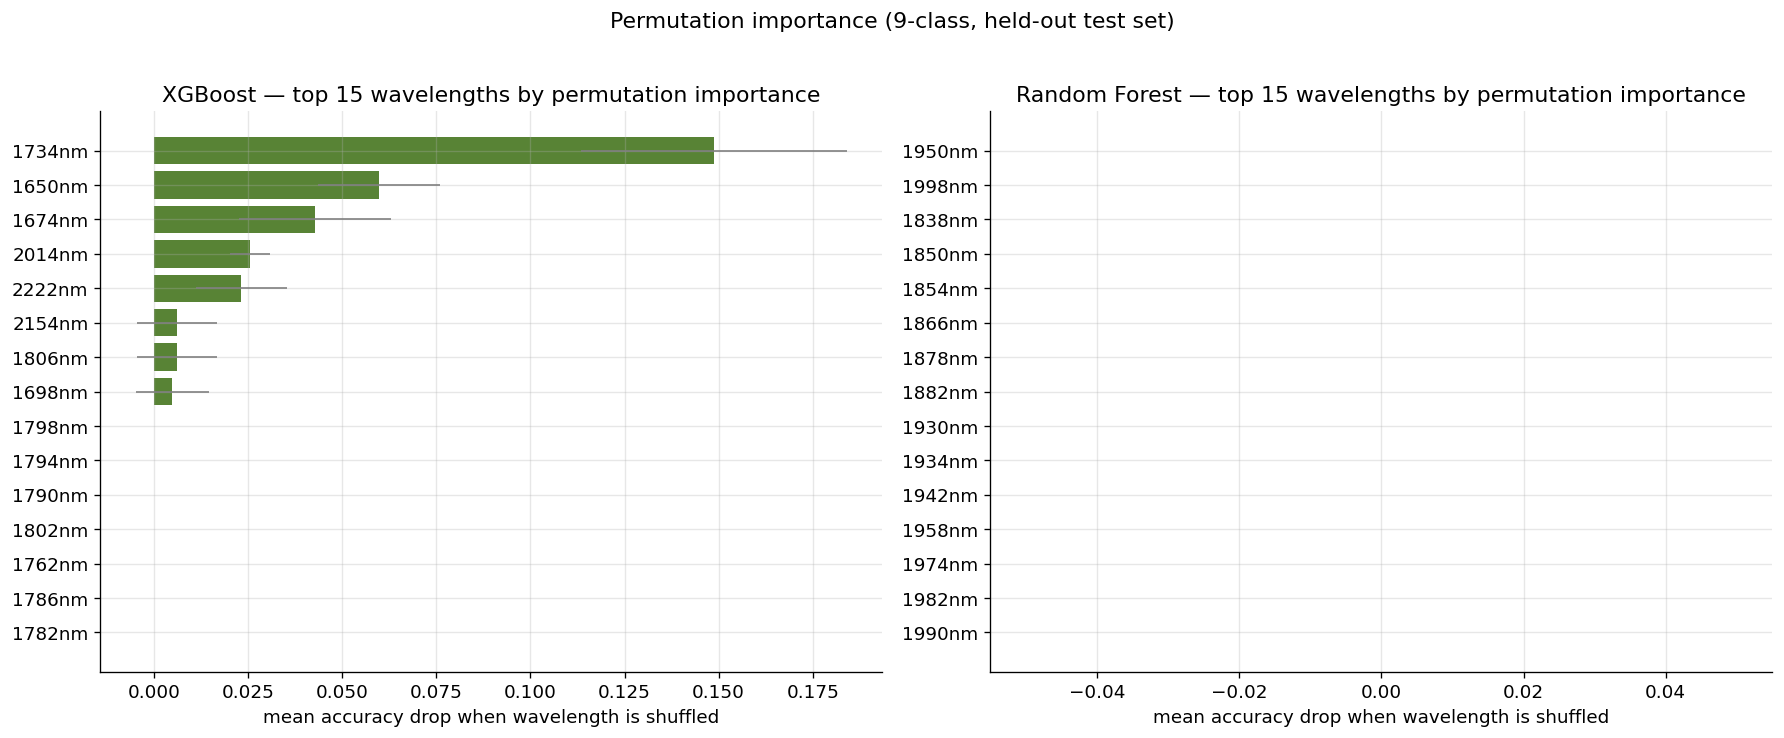

In [9]:
perm_xgb = permutation_importance(xgb9, Xte, yte, n_repeats=20,
                                  random_state=RANDOM_STATE, n_jobs=-1)
perm_rf  = permutation_importance(rf9,  Xte, yte, n_repeats=20,
                                  random_state=RANDOM_STATE, n_jobs=-1)

def top_perm(res, k=15):
    idx = np.argsort(res.importances_mean)[::-1][:k]
    return idx, res.importances_mean[idx], res.importances_std[idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=False)
for ax, (res, name) in zip(axes, [(perm_xgb, 'XGBoost'), (perm_rf, 'Random Forest')]):
    idx, mean, std = top_perm(res)
    ax.barh([feat_names[i] for i in idx][::-1], mean[::-1],
            xerr=std[::-1], color='#3b6d11', alpha=0.85, error_kw=dict(ecolor='grey', lw=1))
    ax.set_title(f'{name} — top 15 wavelengths by permutation importance')
    ax.set_xlabel('mean accuracy drop when wavelength is shuffled')
fig.suptitle('Permutation importance (9-class, held-out test set)', y=1.02)
plt.tight_layout()
plt.savefig('permutation_importance.png', bbox_inches='tight', dpi=130)
plt.show()

## 7. Partial dependence plots (PDP) — the average response curve

A PDP answers: *holding everything else as-is, if I sweep this one wavelength across its range,
how does the model's predicted probability move, on average?* It marginalises out all the other
wavelengths, leaving a clean 1-D curve. A flat line means the wavelength doesn't matter for that
class; a rising/falling line means a monotonic effect; a kink or step reveals the non-linear
thresholds tree models love.

We draw PDPs on the **Random Forest** for the most important wavelengths, targeting the prediction
of the `LVP_12` class (a common vinyl tier) so the curves have a single clear meaning: "probability
this scan is 12-mil vinyl".

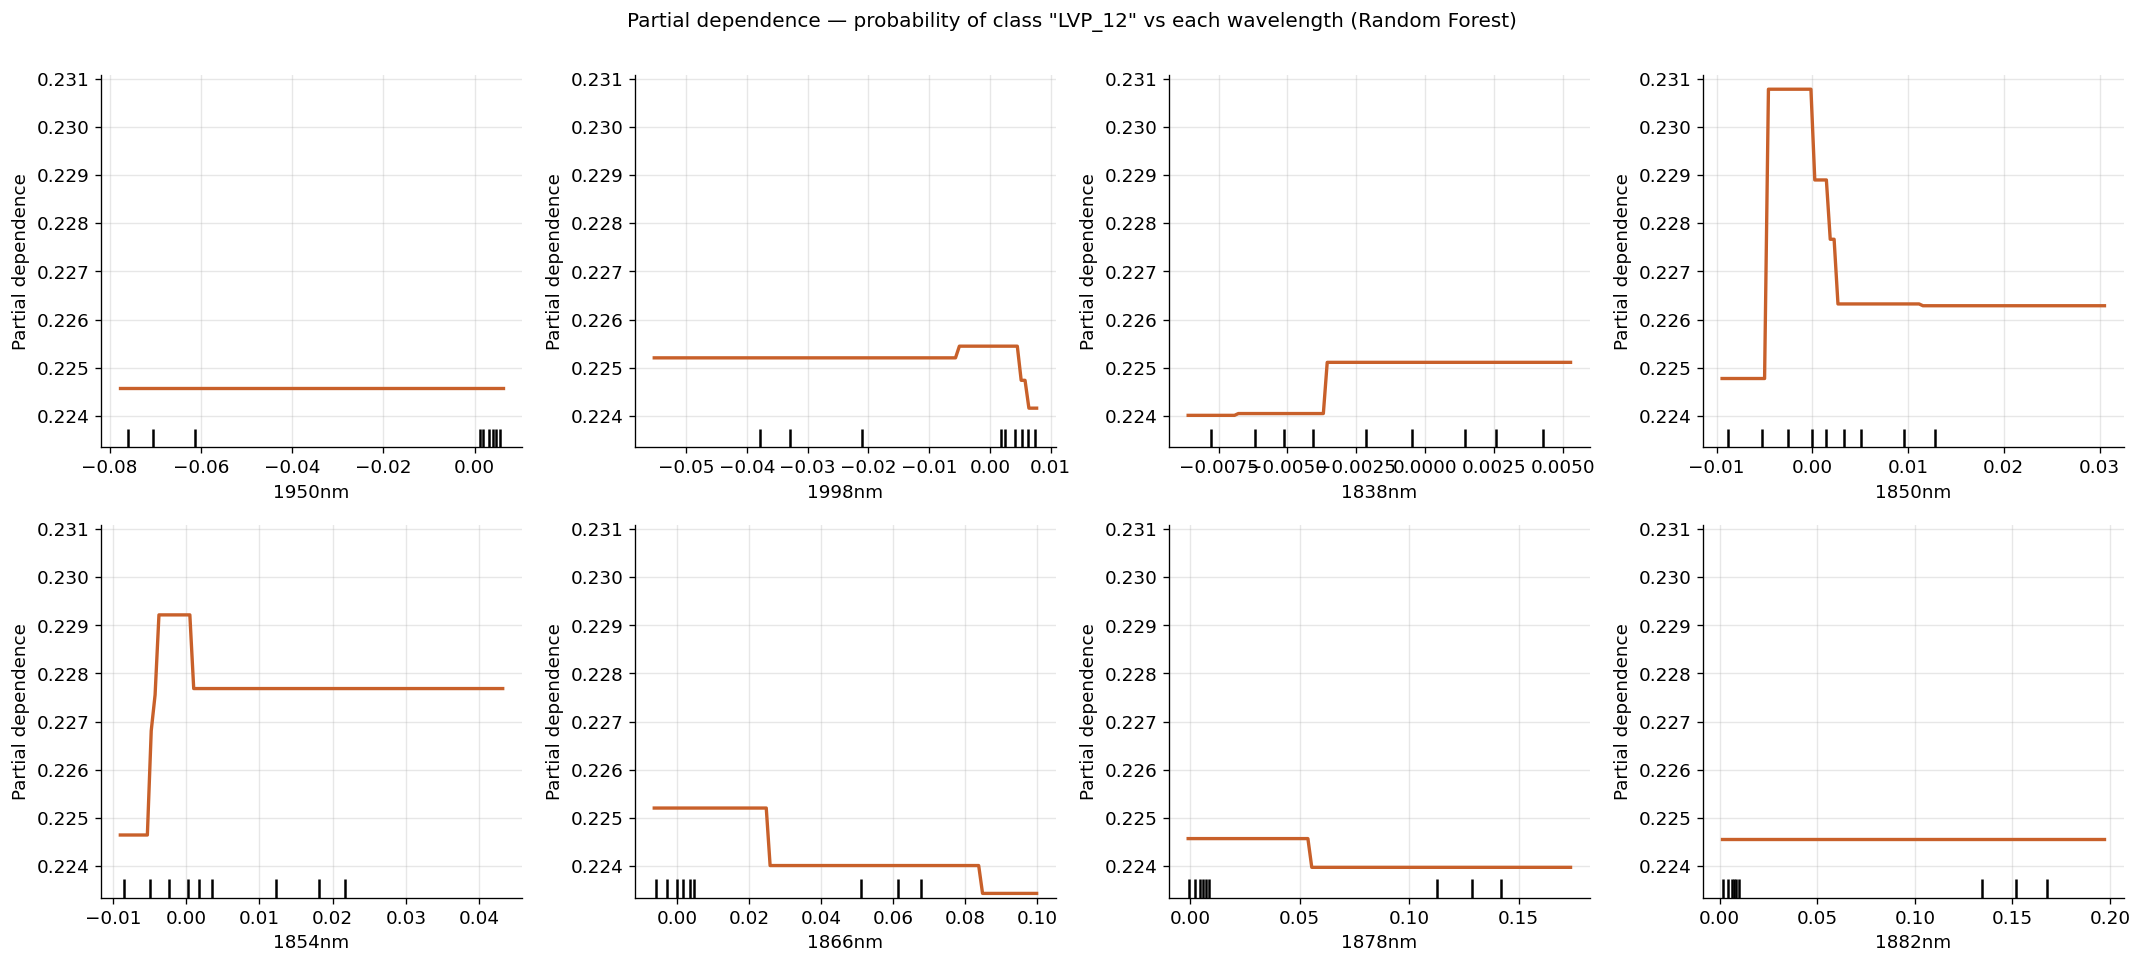

In [10]:
# pick the most important features by RF permutation importance for the PDP grid
pdp_idx = list(np.argsort(perm_rf.importances_mean)[::-1][:8])
target_class = class9_names.index('LVP_12') if 'LVP_12' in class9_names else 0

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
PartialDependenceDisplay.from_estimator(
    rf9, X_all, features=pdp_idx, target=target_class,
    feature_names=feat_names, ax=axes.ravel(), line_kw={'color': '#c8602a', 'lw': 2})
fig.suptitle(f'Partial dependence — probability of class "{class9_names[target_class]}" '
             'vs each wavelength (Random Forest)', y=1.0, fontsize=12)
plt.tight_layout()
plt.savefig('pdp_grid.png', bbox_inches='tight', dpi=130)
plt.show()

## 8. LIME — a simple local story per scan

**LIME (Local Interpretable Model-agnostic Explanations)** takes a different tack from SHAP. To
explain one scan, it generates many slightly-perturbed copies of that scan, asks the big model what
it predicts for each, and then fits a *tiny, transparent linear model* to that local cloud. The
linear model's coefficients are the explanation: "around this scan, these wavelengths push toward
the label with roughly these weights". It's an approximation, valid only *near* the scan being
explained — but it's intuitive and works on any model.

We explain three test scans, including (if one exists) a **misclassified** one — those are the most
educational, because they show *which wavelengths fooled the model*.

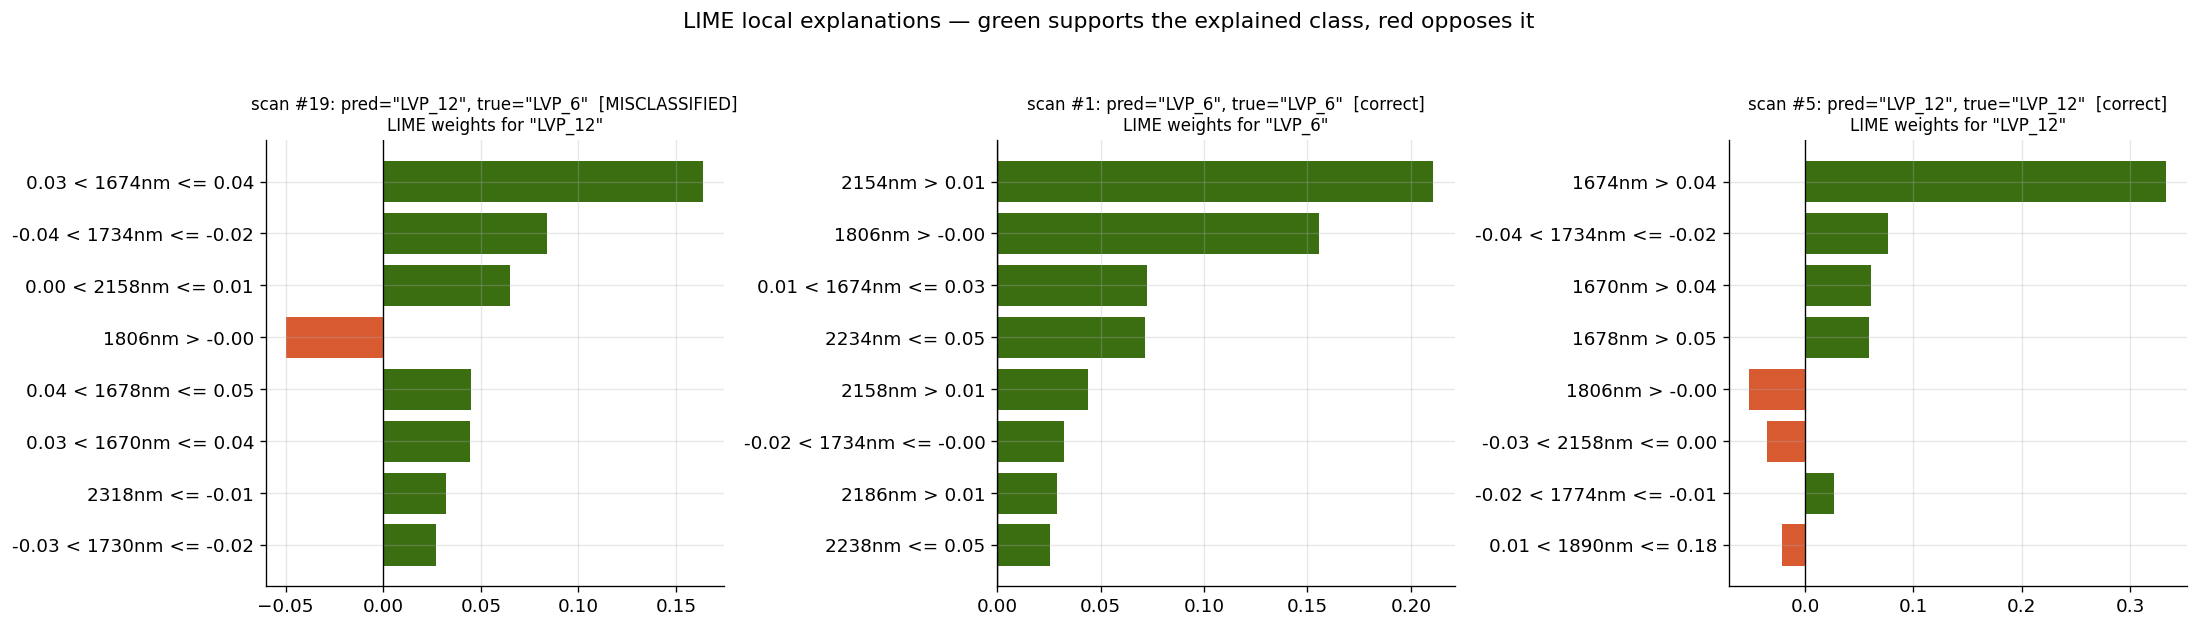

In [11]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    Xtr, feature_names=feat_names, class_names=class9_names,
    discretize_continuous=True, random_state=RANDOM_STATE, mode='classification')

preds_te = xgb9.predict(Xte)
wrong = np.where(preds_te != yte)[0]
pick = list(dict.fromkeys(([wrong[0]] if len(wrong) else []) + [1, 5, 9]))[:3]

fig, axes = plt.subplots(1, len(pick), figsize=(6.2*len(pick), 5))
if len(pick) == 1: axes = [axes]
for ax, i in zip(axes, pick):
    exp = explainer.explain_instance(Xte[i], xgb9.predict_proba,
                                     num_features=8, top_labels=1)
    lbl = exp.available_labels()[0]
    pairs = exp.as_list(label=lbl)
    names = [p[0] for p in pairs][::-1]
    vals  = [p[1] for p in pairs][::-1]
    ax.barh(names, vals, color=['#3b6d11' if v > 0 else '#d85a30' for v in vals])
    ax.axvline(0, color='k', lw=0.8)
    tag = 'MISCLASSIFIED' if preds_te[i] != yte[i] else 'correct'
    ax.set_title(f'scan #{i}: pred="{class9_names[preds_te[i]]}", '
                 f'true="{class9_names[yte[i]]}"  [{tag}]\n'
                 f'LIME weights for "{class9_names[lbl]}"', fontsize=10)
fig.suptitle('LIME local explanations — green supports the explained class, red opposes it', y=1.04)
plt.tight_layout()
plt.savefig('lime_examples.png', bbox_inches='tight', dpi=130)
plt.show()

## 9. Consensus importance — where every method agrees

Each method has blind spots, so the most trustworthy "important wavelengths" are the ones that show
up *no matter how you ask*. We combine **five** rankings:

1. **SHAP** — mean \|SHAP\| over the 9-class model.
2. **Permutation (XGBoost)** — accuracy drop when shuffled.
3. **Permutation (Random Forest)** — same, different model family.
4. **ANOVA F-statistic** — a pure-statistics test (computed here with `f_classif`): how well does
   each wavelength alone separate the 9 classes? This is the same idea as Analysis 7.
5. **RFE rank** — recursive feature elimination with a linear SVM: repeatedly drop the least useful
   wavelength and record the order, like Analysis 5.

We convert each method's scores to **ranks** (rank 1 = most important), average the ranks per
wavelength, and sort. Averaging ranks (rather than raw scores) keeps any single method from
dominating just because its numbers are on a bigger scale. The heatmap then shows, for the top
consensus wavelengths, where each individual method placed them — solid agreement looks like a row
that is bright all the way across.

In [12]:
# 1. SHAP (mean |shap| across classes, 9-class model, on all data for stability)
sv9_all = np.asarray(shap.TreeExplainer(xgb9).shap_values(X_all))
if sv9_all.ndim == 3 and sv9_all.shape[1] == len(class9_names):
    sv9_all = np.transpose(sv9_all, (0, 2, 1))
shap_score = np.abs(sv9_all).mean(axis=(0, 2))

# 2 & 3. permutation importances (already computed)
perm_xgb_score = np.clip(perm_xgb.importances_mean, 0, None)
perm_rf_score  = np.clip(perm_rf.importances_mean, 0, None)

# 4. ANOVA F-statistic
f_score, _ = f_classif(X_all, y9)
f_score = np.nan_to_num(f_score)

# 5. RFE with linear SVM -> ranking_ (1 = kept longest = best)
rfe = RFE(LinearSVC(C=1.0, max_iter=5000, dual=False),
          n_features_to_select=1, step=1)
rfe.fit(StandardScaler().fit_transform(X_all), y9)
rfe_score = -rfe.ranking_          # higher = more important

methods = {
    'SHAP'        : shap_score,
    'Perm (XGB)'  : perm_xgb_score,
    'Perm (RF)'   : perm_rf_score,
    'ANOVA F'     : f_score,
    'RFE'         : rfe_score,
}

# convert each score to a rank (1 = most important). Build the score table with the
# wavelength names as the index FIRST, then rank — so every method stays aligned to its wavelength.
score_df = pd.DataFrame({m: np.asarray(s) for m, s in methods.items()}, index=feat_names)
rank_df  = score_df.rank(ascending=False, method='min')
rank_df['consensus'] = rank_df.mean(axis=1)
top = rank_df.sort_values('consensus').head(20)
print('Top consensus wavelengths:')
print(top[['consensus']].round(1).to_string())

Top consensus wavelengths:
        consensus
1678nm       15.8
1674nm       21.2
1938nm       22.8
1730nm       36.6
1906nm       37.2
1682nm       37.4
2110nm       39.0
1910nm       39.2
2434nm       39.8
1734nm       40.0
2014nm       40.4
1902nm       40.8
1898nm       41.4
1670nm       41.4
1762nm       42.2
2438nm       42.4
2446nm       43.4
1946nm       44.0
1894nm       44.2
1914nm       44.8


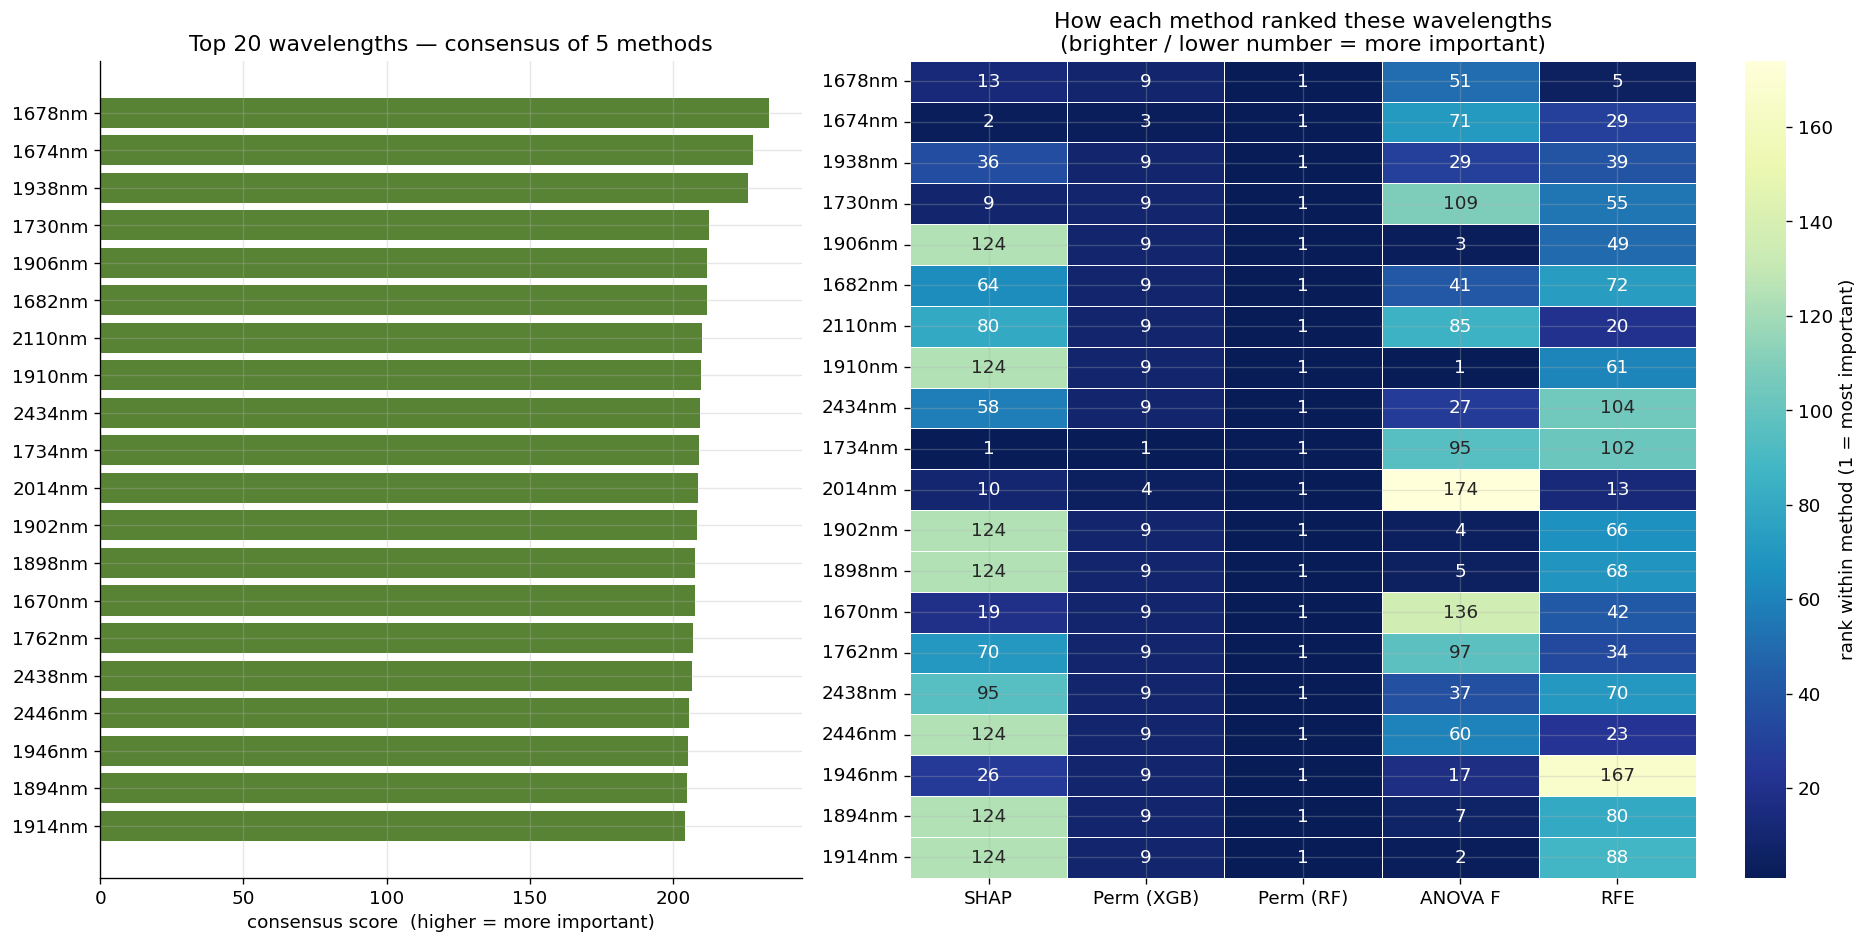

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8),
                               gridspec_kw={'width_ratios': [1, 1.4]})

# left: consensus bar (lower average rank = more important -> invert for bar length)
order = top.index[::-1]
ax1.barh(order, (len(feat_names) - top['consensus'][::-1]),
         color='#3b6d11', alpha=0.85)
ax1.set_xlabel('consensus score  (higher = more important)')
ax1.set_title('Top 20 wavelengths — consensus of 5 methods')

# right: heatmap of per-method rank for those wavelengths (1 = best)
hm = top[list(methods.keys())]
sns.heatmap(hm, ax=ax2, cmap='YlGnBu_r', annot=True, fmt='.0f',
            cbar_kws={'label': 'rank within method (1 = most important)'},
            linewidths=0.5, linecolor='white')
ax2.set_title('How each method ranked these wavelengths\n(brighter / lower number = more important)')
ax2.set_ylabel('')
plt.tight_layout()
plt.savefig('consensus_importance.png', bbox_inches='tight', dpi=130)
plt.show()

**The methods agree, and they agree with the chemistry.** Across SHAP, permutation importance (in
two different model families), ANOVA, and RFE, the same wavelengths rise to the top of the consensus
ranking: a tight **C–H first-overtone cluster around 1670–1740 nm** (1670, 1674, 1678, 1682, 1730,
1734 nm) and the **O–H combination region near 1900–1950 nm** (1898–1946 nm), with secondary
contributions near 2010–2110 nm and at the long-wavelength edge (2434–2446 nm). These are exactly
the bonds where plastic (vinyl, rich in C–H) and wood (cellulose/lignin, rich in O–H and aromatic
C–H) genuinely differ. The model is doing real spectroscopy, not exploiting an artefact — which is
the single most important thing interpretability can tell us.